# Oasis Infobyte Internship

# Level 2 - Task 3

# Fraud Detection

# Credit Card Fraud Detection using Machine Learning

## Import Libraries

In this section, we import all the required Python libraries for data manipulation, visualization, model training, and evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [36]:
df = pd.read_csv("card_transdata.csv")
print(df.shape)
df.head()

(27496, 8)


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


## Load Dataset

In this section, the credit card fraud dataset is loaded into a Pandas DataFrame. The first five records are displayed to verify that the dataset has been imported successfully.

### Observation

- The dataset contains **27,496 rows** and **8 columns**.
- It consists of **7 input features** and **1 target variable (fraud)**.
- The target variable indicates whether a transaction is legitimate (`0`) or fraudulent (`1`).

## Dataset Information

In this section, we examine the dataset structure, data types, and check whether the dataset contains any missing values.

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27496 entries, 0 to 27495
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   distance_from_home              27496 non-null  float64
 1   distance_from_last_transaction  27496 non-null  float64
 2   ratio_to_median_purchase_price  27496 non-null  float64
 3   repeat_retailer                 27496 non-null  float64
 4   used_chip                       27496 non-null  float64
 5   used_pin_number                 27496 non-null  float64
 6   online_order                    27495 non-null  float64
 7   fraud                           27495 non-null  float64
dtypes: float64(8)
memory usage: 1.7 MB


### Observation

### Observation

- The dataset contains **27,496 records** and **8 numerical features**.
- All columns are of **float64** data type.
- Most columns contain complete data, while the **online_order** and **fraud** columns each have **one missing value**.
- The dataset occupies approximately **1.7 MB** of memory.

In [38]:
df.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,27496.000000,27496.000000,27496.000000,27496.000000,27496.000000,27496.000000,27495.000000,27495.000000
mean,27.123694,5.050688,1.807626,0.883801,0.349905,0.102524,0.648154,0.086779
std,63.018835,23.659805,2.666669,0.320469,0.476949,0.303342,0.477555,0.281517
min,0.031670,0.000856,0.011373,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.885667,0.305397,0.479473,1.000000,0.000000,0.000000,0.000000,0.000000
50%,10.125329,1.022600,1.005091,1.000000,0.000000,0.000000,1.000000,0.000000
75%,26.116232,3.431631,2.090165,1.000000,1.000000,0.000000,1.000000,0.000000
max,2353.226927,1872.446884,65.150879,1.000000,1.000000,1.000000,1.000000,1.000000


### Observation

- The statistical summary provides information such as count, mean, standard deviation, minimum, maximum, and quartile values for each feature.
- Most transactions have a relatively short distance from home and the previous transaction, while a few transactions have very large values, indicating the presence of outliers.
- The **fraud** column is a binary target variable where **0 represents a legitimate transaction** and **1 represents a fraudulent transaction**.

## Missing Values

In this section, we check whether the dataset contains any missing (null) values.

In [39]:
df.isnull().sum()

,0
distance_from_home,0
distance_from_last_transaction,0
ratio_to_median_purchase_price,0
repeat_retailer,0
used_chip,0
used_pin_number,0
online_order,1
fraud,1


### Observation

- The dataset contains only **one missing value** in the **online_order** column and **one missing value** in the **fraud** column.
- Since the number of missing values is very small, the incomplete record will be removed during data preprocessing.

## Handling Missing Values

The incomplete record is removed from the dataset to ensure clean and accurate data for machine learning.

In [40]:
df = df.dropna()

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (27495, 8)


### Observation

- The row containing missing values was successfully removed.
- The cleaned dataset now contains **27,495 records** and **8 columns**.
- The dataset is now clean and ready for further preprocessing and analysis.

## Duplicate Values

In this section, we check whether the dataset contains any duplicate records.

In [42]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Observation

- No duplicate records were found in the dataset.
- Therefore, no duplicate removal was required.
- The dataset is clean and ready for exploratory data analysis (EDA) and machine learning.

## Distribution of Fraud Transactions

This visualization shows the distribution of legitimate and fraudulent transactions in the dataset. It helps identify whether the dataset is balanced or imbalanced.

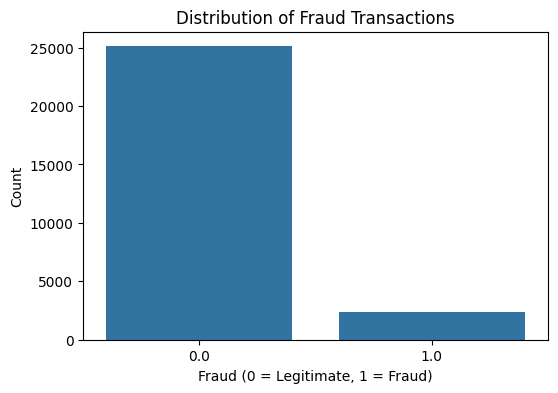

In [43]:
plt.figure(figsize=(6,4))

sns.countplot(x="fraud", data=df)

plt.title("Distribution of Fraud Transactions")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

### Observation

- The dataset contains significantly more **legitimate transactions (Fraud = 0)** than **fraudulent transactions (Fraud = 1)**.
- This indicates that the dataset is **imbalanced**, with legitimate transactions being the majority class.
- Such an imbalance is common in real-world fraud detection problems and should be considered while evaluating the model.

## Correlation Heatmap

A correlation heatmap is used to visualize the relationship between different features in the dataset. It helps identify positively and negatively correlated variables.

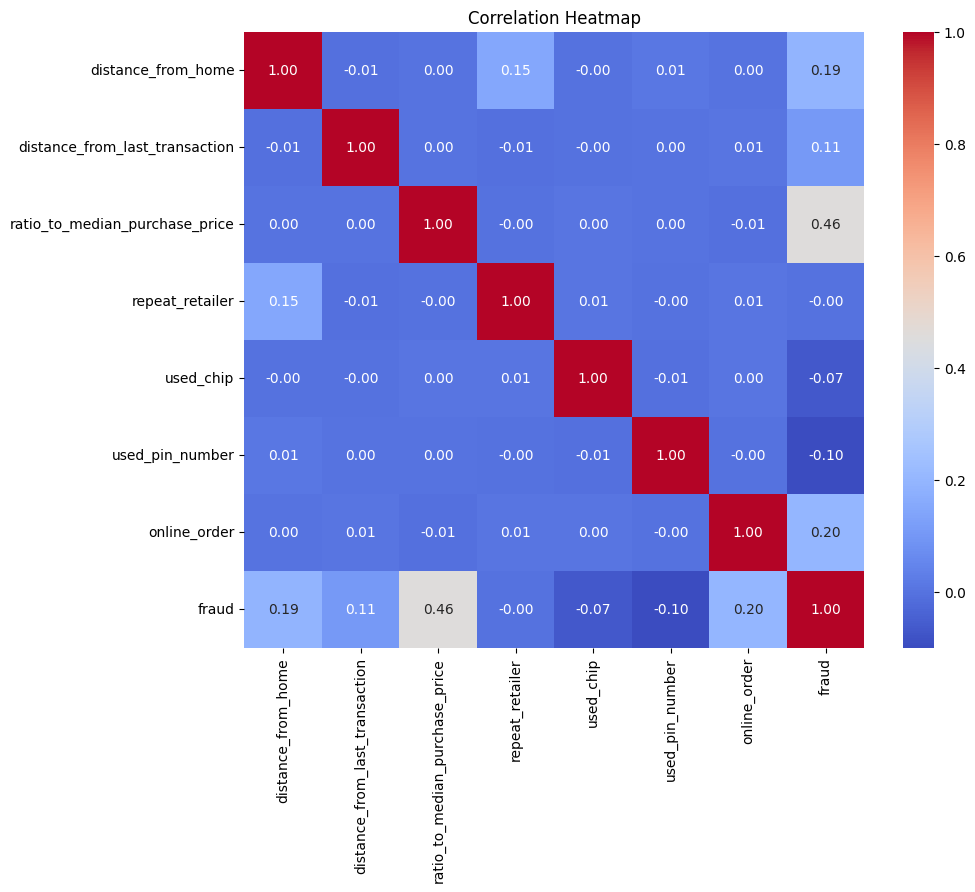

In [44]:
plt.figure(figsize=(10, 8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### Observation

- The heatmap shows the correlation between all features in the dataset.
- Most features have **low correlation** with each other, indicating minimal multicollinearity.
- The feature **ratio_to_median_purchase_price** has the strongest positive correlation with **fraud** (approximately **0.46**).
- Features such as **distance_from_home** and **online_order** also show a positive relationship with fraud, while **used_chip** and **used_pin_number** have a slight negative correlation.

## Feature Selection

The target variable is separated from the input features to prepare the data for model training.

In [45]:
# Input features
X = df.drop("fraud", axis=1)

# Target variable
y = df["fraud"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (27495, 7)
Target Shape: (27495,)


### Observation

- The input features (**X**) contain **27,495 records** and **7 independent variables**.
- The target variable (**y**) contains **27,495 labels** representing whether a transaction is **legitimate (0)** or **fraudulent (1)**.
- The dataset is now ready to be split into training and testing sets for model development.

## Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the machine learning model, while the testing set is used to evaluate its performance on unseen data.

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (21996, 7)
Testing Features: (5499, 7)
Training Target: (21996,)
Testing Target: (5499,)


### Observation

- The dataset was successfully divided into training and testing sets using an 80:20 ratio.
- The training set contains **21,996 records**, while the testing set contains **5,499 records**.
- This split allows the model to learn from the training data and evaluate its performance on unseen testing data.

## Model Training

A Random Forest Classifier is used to train the fraud detection model. Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting.

In [47]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## Model Prediction

The trained Random Forest model is used to predict whether each transaction in the testing dataset is legitimate or fraudulent.

In [48]:
# Predict on test data
y_pred = model.predict(X_test)

# Display first 10 predictions
print(y_pred[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


## Model Evaluation

The performance of the trained Random Forest model is evaluated using Accuracy Score, Confusion Matrix, and Classification Report.

In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.999818148754319

Confusion Matrix:
[[5005    0]
 [   1  493]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5005
         1.0       1.00      1.00      1.00       494

    accuracy                           1.00      5499
   macro avg       1.00      1.00      1.00      5499
weighted avg       1.00      1.00      1.00      5499



### Observation

- The Random Forest Classifier achieved an **Accuracy Score of 99.98%**, demonstrating excellent performance in detecting fraudulent transactions.
- The confusion matrix shows that **5005 legitimate transactions** and **493 fraudulent transactions** were correctly classified.
- Only **one fraudulent transaction** was misclassified, indicating that the model performs exceptionally well on the given dataset.
- The classification report shows precision, recall, and F1-score values close to **1.00**, confirming the reliability of the model.

# Conclusion

This project successfully developed a **Credit Card Fraud Detection** model using the **Random Forest Classifier**.

The dataset was explored through exploratory data analysis (EDA), including class distribution and correlation analysis. Data preprocessing involved handling missing values, checking duplicate records, selecting relevant features, and splitting the dataset into training and testing sets.

The trained model achieved an **Accuracy Score of 99.98%**, correctly identifying almost all legitimate and fraudulent transactions. The confusion matrix and classification report further demonstrated the effectiveness of the model, with excellent precision, recall, and F1-score values.

Overall, this project demonstrates the practical application of machine learning in detecting fraudulent financial transactions and highlights the effectiveness of the Random Forest algorithm for fraud detection.